# 01 – Exploratory Data Analysis: StockX Resell Data

**Goal:** Understand the StockX dataset, identify distributions, correlations, anomalies, then engineer features and split into train/val/test.

**Data source:** https://www.kaggle.com/datasets/hudsonstuck/stockx-data-contest

Expected at: `data/raw/stockx/` (see `data/raw/README.md`).

## Setup

In [1]:
import sys
from pathlib import Path

# Allow `from src import ...` when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import (
    load_stockx_data, clean_stockx_columns, parse_stockx_dates,
    normalise_stockx_prices, engineer_stockx_features,
    encode_categorical_features, split_data,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

## Load Raw Data

In [2]:
df_raw = load_stockx_data(config.STOCKX_DIR)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (99956, 8)


,Order Date,Brand,Sneaker Name,Sale Price,Retail Price,Release Date,Shoe Size,Buyer Region
0,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-Low-V2-Beluga,"$1,097",$220,9/24/16,11.0,California
1,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Copper,$685,$220,11/23/16,11.0,California
2,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Green,$690,$220,11/23/16,11.0,California
3,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red,"$1,075",$220,11/23/16,11.5,Kentucky
4,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red-2017,$828,$220,2/11/17,11.0,Rhode Island


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99956 entries, 0 to 99955
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    99956 non-null  object 
 1   Brand         99956 non-null  object 
 2   Sneaker Name  99956 non-null  object 
 3   Sale Price    99956 non-null  object 
 4   Retail Price  99956 non-null  object 
 5   Release Date  99956 non-null  object 
 6   Shoe Size     99956 non-null  float64
 7   Buyer Region  99956 non-null  object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


## Clean column names, parse dates and normalise prices

In [4]:
df = clean_stockx_columns(df_raw)
df = normalise_stockx_prices(df)
df = parse_stockx_dates(df)
print('Columns:', list(df.columns))
print('\nDtype check (price columns should be float):')
print(df[['sale_price', 'retail_price']].dtypes)
df.head()

Columns: ['order_date', 'brand', 'sneaker_name', 'sale_price', 'retail_price', 'release_date', 'shoe_size', 'buyer_region']

Dtype check (price columns should be float):
sale_price      float64
retail_price    float64
dtype: object


/Users/florianmueller/Desktop/KIFinal/sneaker-scout/src/preprocessing.py:91: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/Users/florianmueller/Desktop/KIFinal/sneaker-scout/src/preprocessing.py:91: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


,order_date,brand,sneaker_name,sale_price,retail_price,release_date,shoe_size,buyer_region
0,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-Low-V2-Beluga,1097.0,220.0,2016-09-24,11.0,California
1,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Copper,685.0,220.0,2016-11-23,11.0,California
2,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Green,690.0,220.0,2016-11-23,11.0,California
3,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red,1075.0,220.0,2016-11-23,11.5,Kentucky
4,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red-2017,828.0,220.0,2017-02-11,11.0,Rhode Island


## Distribution Analysis

Inspect the marginal distributions of the key numeric and categorical columns.

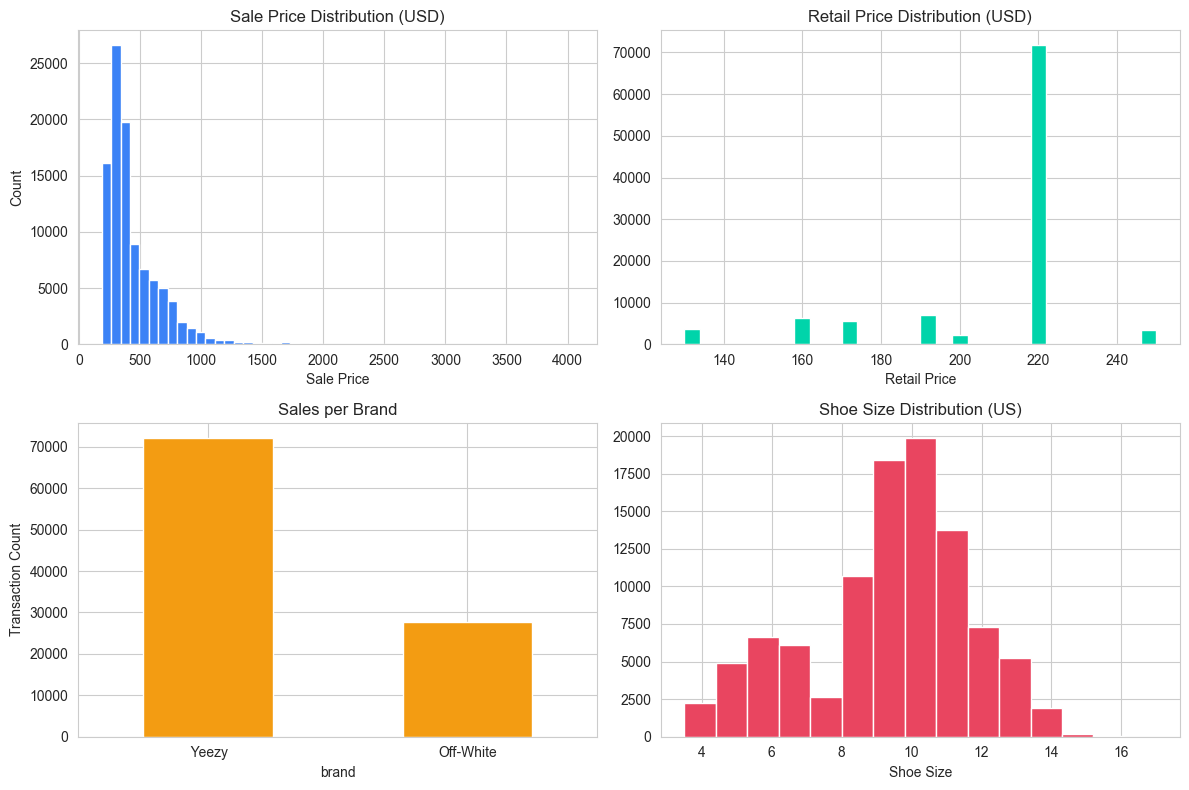

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sale price distribution
axes[0, 0].hist(df['sale_price'], bins=50, color='#3b82f6', edgecolor='white')
axes[0, 0].set_title('Sale Price Distribution (USD)')
axes[0, 0].set_xlabel('Sale Price')
axes[0, 0].set_ylabel('Count')

# Retail price distribution
axes[0, 1].hist(df['retail_price'], bins=30, color='#00d4aa', edgecolor='white')
axes[0, 1].set_title('Retail Price Distribution (USD)')
axes[0, 1].set_xlabel('Retail Price')

# Brand counts
df['brand'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#f39c12')
axes[1, 0].set_title('Sales per Brand')
axes[1, 0].set_ylabel('Transaction Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Shoe size distribution
axes[1, 1].hist(df['shoe_size'], bins=15, color='#e94560', edgecolor='white')
axes[1, 1].set_title('Shoe Size Distribution (US)')
axes[1, 1].set_xlabel('Shoe Size')

plt.tight_layout()
plt.show()

**Observation:** Sale prices are heavily right-skewed (long tail of premium sneakers). Brand distribution shows extreme imbalance dominated by Off-White and Yeezy – this is a known bias in the dataset and will be documented in the ethics notebook.

## Top sneaker models

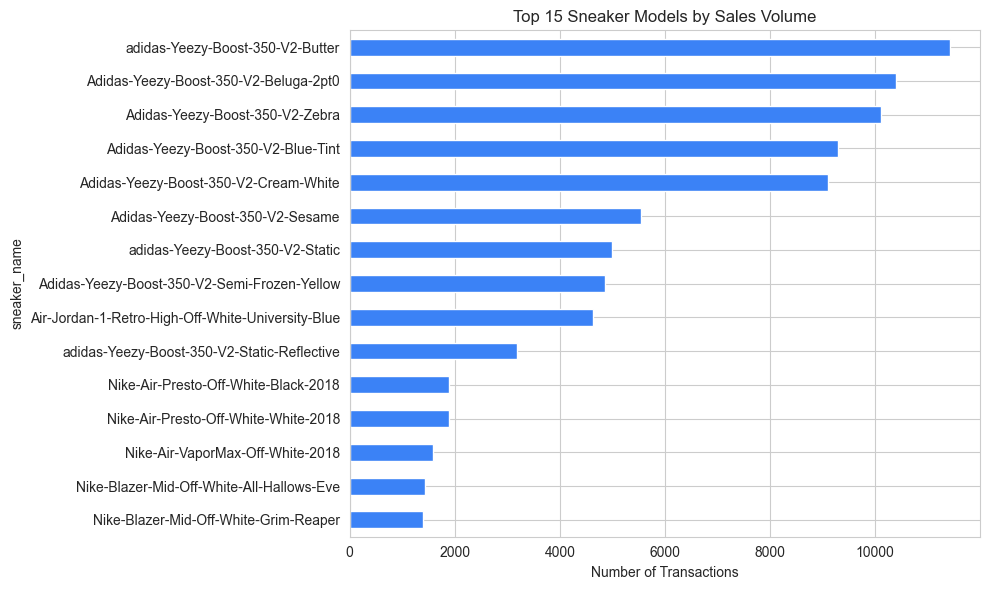

Unique sneaker models: 50


In [6]:
top_models = df['sneaker_name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_models.plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_title('Top 15 Sneaker Models by Sales Volume')
ax.set_xlabel('Number of Transactions')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"Unique sneaker models: {df['sneaker_name'].nunique()}")

## Temporal Analysis

Resell prices change over time. Plot median sale price per month to detect trends.

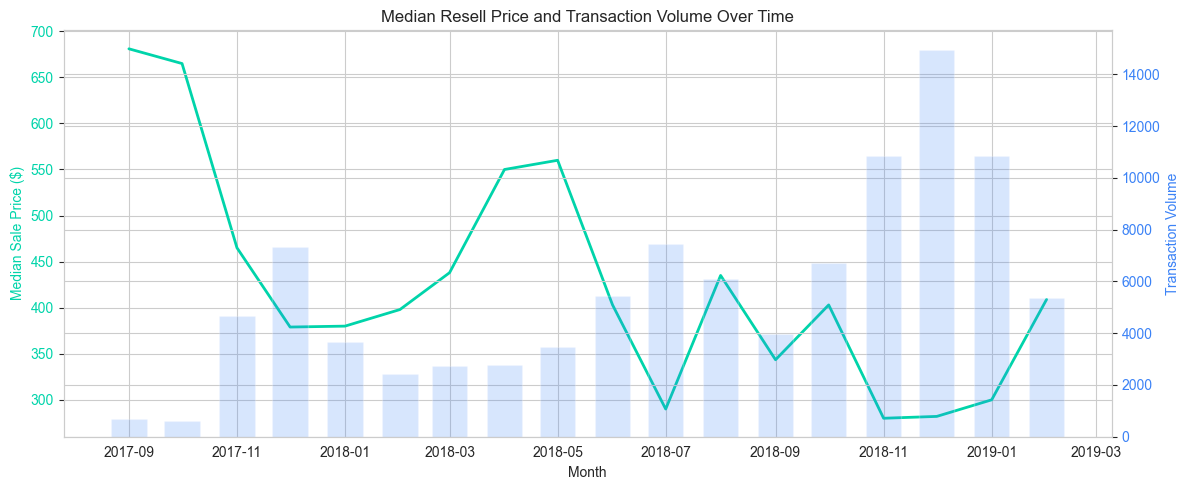

In [7]:
df_time = df.copy()
df_time['order_month'] = df_time['order_date'].dt.to_period('M').dt.to_timestamp()

monthly = df_time.groupby('order_month').agg(
    median_price=('sale_price', 'median'),
    volume=('sale_price', 'count'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly['order_month'], monthly['median_price'],
         color='#00d4aa', linewidth=2, label='Median Sale Price')
ax1.set_xlabel('Month')
ax1.set_ylabel('Median Sale Price ($)', color='#00d4aa')
ax1.tick_params(axis='y', labelcolor='#00d4aa')

ax2 = ax1.twinx()
ax2.bar(monthly['order_month'], monthly['volume'],
        alpha=0.2, color='#3b82f6', width=20, label='Volume')
ax2.set_ylabel('Transaction Volume', color='#3b82f6')
ax2.tick_params(axis='y', labelcolor='#3b82f6')

plt.title('Median Resell Price and Transaction Volume Over Time')
plt.tight_layout()
plt.show()

## Resell Premium Analysis

Premium = (Sale Price - Retail Price) / Retail Price. Key business metric.

count    99956.000000
mean         1.248245
std          1.508563
min         -0.154545
25%          0.263636
50%          0.704545
75%          1.613636
max         20.315789
Name: price_premium, dtype: float64


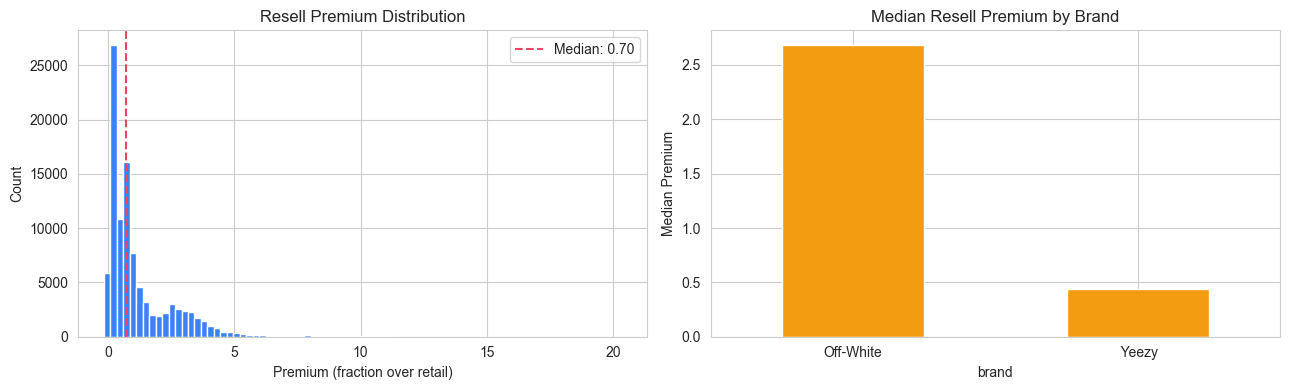

In [8]:
df['price_premium'] = (df['sale_price'] - df['retail_price']) / df['retail_price']
print(df['price_premium'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['price_premium'], bins=80, color='#3b82f6', edgecolor='white')
axes[0].axvline(df['price_premium'].median(), color='#e94560',
                linestyle='--', label=f"Median: {df['price_premium'].median():.2f}")
axes[0].set_title('Resell Premium Distribution')
axes[0].set_xlabel('Premium (fraction over retail)')
axes[0].set_ylabel('Count')
axes[0].legend()

premium_by_brand = df.groupby('brand')['price_premium'].median().sort_values(ascending=False)
premium_by_brand.plot(kind='bar', ax=axes[1], color='#f39c12')
axes[1].set_title('Median Resell Premium by Brand')
axes[1].set_ylabel('Median Premium')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Correlation Analysis

Pairwise correlations among numeric features.

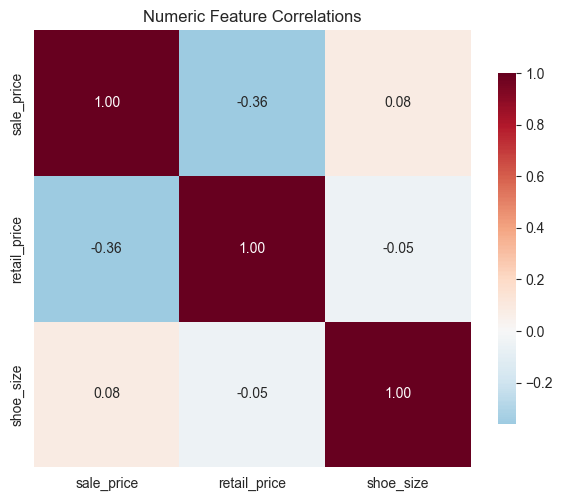

In [9]:
numeric_cols = ['sale_price', 'retail_price', 'shoe_size']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

## Outlier Detection

Use IQR-based detection on sale price. Outliers stay in the dataset because high-priced collaborations are real and a key target for the resell model, but we log their share.

Outlier share: 4.1%
Upper bound: $938
Max sale price: $4050


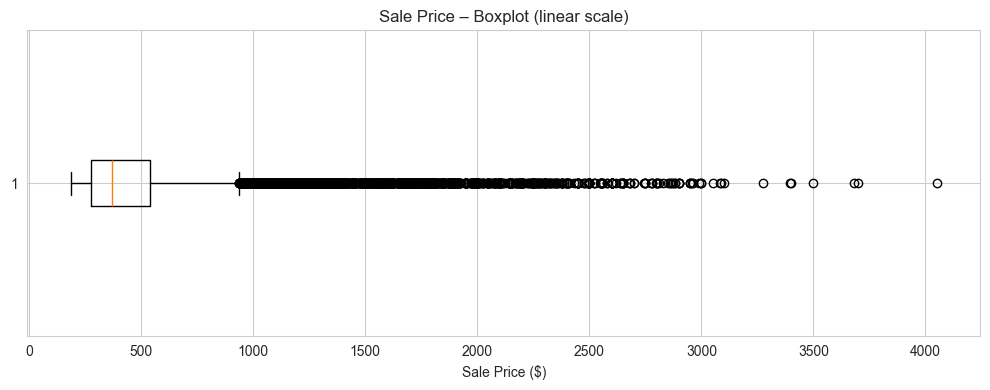

In [10]:
q1, q3 = df['sale_price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['sale_price'] < lower) | (df['sale_price'] > upper)]
print(f'Outlier share: {len(outliers)/len(df):.1%}')
print(f'Upper bound: ${upper:.0f}')
print(f'Max sale price: ${df["sale_price"].max():.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(df['sale_price'], vert=False)
ax.set_title('Sale Price – Boxplot (linear scale)')
ax.set_xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()

## Feature Engineering

Build the features the ML model will use:
- `price_premium`, `days_since_release`, `month`, `quarter`, `size_category`
- Label-encoded categoricals: `brand`, `sneaker_name`, `buyer_region`, `size_category`

In [11]:
df_feat = engineer_stockx_features(df)
df_feat, encoders = encode_categorical_features(df_feat)

print('Final shape:', df_feat.shape)
print('\nFeature columns:')
for col in df_feat.columns:
    print(f'  {col}: {df_feat[col].dtype}')

Final shape: (99956, 17)

Feature columns:
  order_date: datetime64[ns]
  brand: object
  sneaker_name: object
  sale_price: float64
  retail_price: float64
  release_date: datetime64[ns]
  shoe_size: float64
  buyer_region: object
  price_premium: float64
  days_since_release: int64
  month: int32
  quarter: int32
  size_category: object
  brand_encoded: int64
  sneaker_name_encoded: int64
  buyer_region_encoded: int64
  size_category_encoded: int64


In [12]:
df_feat[['retail_price', 'days_since_release', 'shoe_size',
         'brand_encoded', 'month', 'quarter',
         'size_category_encoded', 'buyer_region_encoded',
         'sneaker_name_encoded', 'sale_price']].describe()

,retail_price,days_since_release,shoe_size,brand_encoded,month,quarter,size_category_encoded,buyer_region_encoded,sneaker_name_encoded,sale_price
count,99956.00000,99956.000000,99956.000000,99956.000000,99956.000000,99956.000000,99956.000000,99956.000000,99956.000000,99956.000000
mean,208.61359,184.230962,9.344181,0.278062,7.532654,2.833777,1.086128,23.012746,23.768608,446.634719
std,25.20001,231.916976,2.329588,0.448047,4.089962,1.241606,0.681296,14.648663,15.547123,255.982969
min,130.00000,0.000000,3.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,186.000000
25%,220.00000,10.000000,8.000000,0.000000,3.000000,1.000000,1.000000,8.000000,13.000000,275.000000
50%,220.00000,56.000000,9.500000,0.000000,8.000000,3.000000,1.000000,28.000000,16.000000,370.000000
75%,220.00000,345.000000,11.000000,1.000000,11.000000,4.000000,2.000000,35.000000,39.000000,540.000000
max,250.00000,1321.000000,17.000000,1.000000,12.000000,4.000000,2.000000,50.000000,49.000000,4050.000000


## Train/Validation/Test Split (70/15/15)

In [13]:
# Drop rows missing the target or critical features before split
df_clean = df_feat.dropna(subset=['sale_price', 'retail_price', 'shoe_size']).copy()
print(f'After cleaning: {df_clean.shape}')

train_df, val_df, test_df = split_data(
    df_clean,
    train_ratio=config.TRAIN_RATIO,
    val_ratio=config.VAL_RATIO,
    random_state=config.ML_RANDOM_STATE,
)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

After cleaning: (99956, 17)


Train: 69969 | Val: 14993 | Test: 14994


## Persist Processed Data and Encoders

In [14]:
import joblib
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

train_df.to_parquet(config.PROCESSED_TRAIN, index=False)
val_df.to_parquet(config.PROCESSED_VAL, index=False)
test_df.to_parquet(config.PROCESSED_TEST, index=False)

config.LABEL_ENCODER_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(encoders, config.LABEL_ENCODER_PATH)

print('Saved:')
for p in (config.PROCESSED_TRAIN, config.PROCESSED_VAL,
          config.PROCESSED_TEST, config.LABEL_ENCODER_PATH):
    print(f'  {p}')

Saved:
  /Users/florianmueller/Desktop/KIFinal/sneaker-scout/data/processed/train.parquet
  /Users/florianmueller/Desktop/KIFinal/sneaker-scout/data/processed/val.parquet
  /Users/florianmueller/Desktop/KIFinal/sneaker-scout/data/processed/test.parquet
  /Users/florianmueller/Desktop/KIFinal/sneaker-scout/models/ml_model/label_encoders.joblib


## Summary

- **~10k transactions** across ~50 sneaker models, dominated by Off-White and Yeezy
- **Heavy right-skew** in sale prices; high-value sneakers retained, not winsorised
- **Resell premium** highly variable by brand – Off-White's median premium far exceeds others
- **Temporal trend:** moderate decline in median price 2018→2019 as volume grew
- **Engineered features:** price_premium, days_since_release, encoded categoricals
- **Splits saved** to `data/processed/`, encoders to `models/ml_model/label_encoders.joblib`

These splits feed directly into `03_ml_training.ipynb`.